<a href="https://colab.research.google.com/github/jiwonojo/Data-Capstone-Design---2026/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%88%84%EC%88%98_%EB%B3%80%EC%88%98_%EC%8B%A4%ED%97%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1
# 라이브러리 불러오기
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [ ]:
# ==========================================
# CELL 2
# 데이터 불러오기
# ==========================================

train = pd.read_csv('/content/train_preprocessed.csv')
test = pd.read_csv('/content/test_preprocessed.csv')

TARGET = 'Fraud_Label'

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.columns)

Train shape: (40000, 23)
Test shape: (10000, 23)
Index(['Transaction_Amount', 'Transaction_Type', 'Account_Balance',
       'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type',
       'Card_Age', 'Transaction_Distance', 'Authentication_Method',
       'Risk_Score', 'Is_Weekend', 'Month', 'Day', 'Hour', 'Amount_to_Balance',
       'Is_Night', 'Fraud_Label'],
      dtype='object')


In [ ]:
# ==========================================
# CELL 3
# 공통 함수 정의
# ==========================================

def prepare_data(train, test, target, remove_features=None):
    if remove_features is None:
        remove_features = []

    X = train.drop(columns=[target])
    y = train[target]

    X_test = test.drop(columns=[target])
    y_test = test[target]

    X = X.drop(columns=remove_features, errors='ignore')
    X_test = X_test.drop(columns=remove_features, errors='ignore')

    categorical_cols = [
        'Transaction_Type',
        'Device_Type',
        'Location',
        'Merchant_Category',
        'Card_Type',
        'Authentication_Method'
    ]

    existing_categorical_cols = [
        col for col in categorical_cols
        if col in X.columns
    ]

    X = pd.get_dummies(
        X,
        columns=existing_categorical_cols,
        drop_first=True
    )

    X_test = pd.get_dummies(
        X_test,
        columns=existing_categorical_cols,
        drop_first=True
    )

    X, X_test = X.align(
        X_test,
        join='left',
        axis=1,
        fill_value=0
    )

    return X, y, X_test, y_test


def evaluate_model(model, X_data, y_data, threshold=0.5, name=""):
    proba = model.predict_proba(X_data)[:, 1]
    pred = (proba >= threshold).astype(int)

    result = {
        "name": name,
        "accuracy": accuracy_score(y_data, pred),
        "precision": precision_score(y_data, pred, zero_division=0),
        "recall": recall_score(y_data, pred, zero_division=0),
        "f1": f1_score(y_data, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_data, proba)
    }

    return result, pred, proba


def find_best_threshold(y_true, proba):
    thresholds = np.arange(0.1, 0.91, 0.01)
    results = []

    for th in thresholds:
        pred = (proba >= th).astype(int)

        results.append({
            "threshold": th,
            "accuracy": accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0)
        })

    threshold_df = pd.DataFrame(results)
    best_row = threshold_df.loc[threshold_df["f1"].idxmax()]

    return best_row["threshold"], threshold_df


def run_experiment(train, test, target, remove_features, experiment_name):
    print("=" * 80)
    print(experiment_name)
    print("Removed features:", remove_features)
    print("=" * 80)

    X, y, X_test, y_test = prepare_data(
        train,
        test,
        target,
        remove_features=remove_features
    )

    print("Feature count:", X.shape[1])

    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    print("scale_pos_weight:", scale_pos_weight)

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)

    valid_result_05, valid_pred_05, valid_proba = evaluate_model(
        model,
        X_valid,
        y_valid,
        threshold=0.5,
        name=experiment_name + " valid threshold 0.5"
    )

    best_threshold, threshold_df = find_best_threshold(y_valid, valid_proba)

    valid_result_best, valid_pred_best, _ = evaluate_model(
        model,
        X_valid,
        y_valid,
        threshold=best_threshold,
        name=experiment_name + " valid best threshold"
    )

    test_result_best, test_pred_best, test_proba = evaluate_model(
        model,
        X_test,
        y_test,
        threshold=best_threshold,
        name=experiment_name + " test best threshold"
    )

    print("\nValidation threshold 0.5")
    print(valid_result_05)

    print("\nBest threshold from validation:", best_threshold)

    print("\nValidation best threshold")
    print(valid_result_best)
    print(confusion_matrix(y_valid, valid_pred_best))

    print("\nTest best threshold")
    print(test_result_best)
    print(confusion_matrix(y_test, test_pred_best))

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 15 Feature Importance")
    display(feature_importance.head(15))

    return {
        "experiment_name": experiment_name,
        "removed_features": remove_features,
        "feature_count": X.shape[1],
        "best_threshold": best_threshold,
        "valid_05": valid_result_05,
        "valid_best": valid_result_best,
        "test_best": test_result_best,
        "feature_importance": feature_importance,
        "threshold_df": threshold_df,
        "model": model
    }

In [ ]:
# ==========================================
# CELL 4
# 실험 1: 아무 변수도 제거하지 않은 모델
# leakage 포함 가능성이 높은 원본 성능 확인
# ==========================================

result_all = run_experiment(
    train=train,
    test=test,
    target=TARGET,
    remove_features=[],
    experiment_name="Model 1 - All Features"
)

Model 1 - All Features
Removed features: []
Feature count: 35
scale_pos_weight: 2.1119323154721386

Validation threshold 0.5
{'name': 'Model 1 - All Features valid threshold 0.5', 'accuracy': 0.998875, 'precision': 0.9965116279069768, 'recall': 1.0, 'f1': 0.9982527664531159, 'roc_auc': np.float64(0.9999921191916383)}

Best threshold from validation: 0.1

Validation best threshold
{'name': 'Model 1 - All Features valid best threshold', 'accuracy': 0.998875, 'precision': 0.9965116279069768, 'recall': 1.0, 'f1': 0.9982527664531159, 'roc_auc': np.float64(0.9999921191916383)}
[[5420    9]
 [   0 2571]]

Test best threshold
{'name': 'Model 1 - All Features test best threshold', 'accuracy': 0.9995, 'precision': 0.9984462399005594, 'recall': 1.0, 'f1': 0.9992225159384233, 'roc_auc': np.float64(0.99999752368901)}
[[6782    5]
 [   0 3213]]

Top 15 Feature Importance


,feature,importance
6,Failed_Transaction_Count_7d,0.634246
9,Risk_Score,0.356660
25,Merchant_Category_1,0.001299
11,Month,0.001122
0,Transaction_Amount,0.000613
1,Account_Balance,0.000573
21,Location_1,0.000559
30,Card_Type_2,0.000534
7,Card_Age,0.000500
5,Avg_Transaction_Amount_7d,0.000460


In [ ]:
# ==========================================
# CELL 5
# 실험 2: 강한 leakage 의심 변수 2개 제거
# ==========================================

strong_leakage_features = [
    'Risk_Score',
    'Failed_Transaction_Count_7d'
]

result_remove_2 = run_experiment(
    train=train,
    test=test,
    target=TARGET,
    remove_features=strong_leakage_features,
    experiment_name="Model 2 - Remove Risk_Score and Failed_Transaction_Count_7d"
)

Model 2 - Remove Risk_Score and Failed_Transaction_Count_7d
Removed features: ['Risk_Score', 'Failed_Transaction_Count_7d']
Feature count: 33
scale_pos_weight: 2.1119323154721386

Validation threshold 0.5
{'name': 'Model 2 - Remove Risk_Score and Failed_Transaction_Count_7d valid threshold 0.5', 'accuracy': 0.509125, 'precision': 0.31852248394004284, 'recall': 0.46285492026448855, 'f1': 0.37735849056603776, 'roc_auc': np.float64(0.4992127788883747)}

Best threshold from validation: 0.43999999999999984

Validation best threshold
{'name': 'Model 2 - Remove Risk_Score and Failed_Transaction_Count_7d valid best threshold', 'accuracy': 0.32425, 'precision': 0.3220785741182377, 'recall': 0.9980552314274601, 'f1': 0.48699943063199846, 'roc_auc': np.float64(0.4992127788883747)}
[[  28 5401]
 [   5 2566]]

Test best threshold
{'name': 'Model 2 - Remove Risk_Score and Failed_Transaction_Count_7d test best threshold', 'accuracy': 0.3224, 'precision': 0.32129601765472965, 'recall': 0.9968876439464

,feature,importance
29,Card_Type_3,0.067156
13,Is_Night,0.055269
21,Location_3,0.041251
3,Previous_Fraudulent_Activity,0.039342
19,Location_1,0.036614
24,Merchant_Category_2,0.034603
10,Day,0.034449
30,Authentication_Method_1,0.033843
0,Transaction_Amount,0.033652
18,Device_Type_2,0.033094


In [ ]:
# ==========================================
# CELL 6
# 실험 3: 추가 의심 변수까지 제거
# ==========================================

suspicious_features = [
    'Risk_Score',
    'Failed_Transaction_Count_7d',
    'Previous_Fraudulent_Activity',
    'Daily_Transaction_Count',
    'Avg_Transaction_Amount_7d'
]

result_remove_5 = run_experiment(
    train=train,
    test=test,
    target=TARGET,
    remove_features=suspicious_features,
    experiment_name="Model 3 - Remove All Suspicious Features"
)

Model 3 - Remove All Suspicious Features
Removed features: ['Risk_Score', 'Failed_Transaction_Count_7d', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d']
Feature count: 30
scale_pos_weight: 2.1119323154721386

Validation threshold 0.5
{'name': 'Model 3 - Remove All Suspicious Features valid threshold 0.5', 'accuracy': 0.51425, 'precision': 0.32079585718179343, 'recall': 0.4577985219758849, 'f1': 0.37724358974358974, 'roc_auc': np.float64(0.50349119810425)}

Best threshold from validation: 0.1

Validation best threshold
{'name': 'Model 3 - Remove All Suspicious Features valid best threshold', 'accuracy': 0.321375, 'precision': 0.321375, 'recall': 1.0, 'f1': 0.4864251253429193, 'roc_auc': np.float64(0.50349119810425)}
[[   0 5429]
 [   0 2571]]

Test best threshold
{'name': 'Model 3 - Remove All Suspicious Features test best threshold', 'accuracy': 0.3213, 'precision': 0.3213, 'recall': 1.0, 'f1': 0.4863392113827291, 'roc_auc': np.float64(0.49217715

,feature,importance
29,Authentication_Method_3,0.061009
26,Card_Type_3,0.047217
16,Location_1,0.045415
0,Transaction_Amount,0.044714
15,Device_Type_2,0.042226
7,Day,0.041378
14,Device_Type_1,0.041295
17,Location_2,0.041270
1,Account_Balance,0.040795
27,Authentication_Method_1,0.039821


In [ ]:
# ==========================================
# CELL 7
# 세 모델 성능 비교표
# ==========================================

summary = pd.DataFrame([
    {
        "model": result_all["experiment_name"],
        "removed_features": ", ".join(result_all["removed_features"]) if result_all["removed_features"] else "None",
        "feature_count": result_all["feature_count"],
        "best_threshold": result_all["best_threshold"],
        "valid_f1": result_all["valid_best"]["f1"],
        "valid_roc_auc": result_all["valid_best"]["roc_auc"],
        "test_f1": result_all["test_best"]["f1"],
        "test_roc_auc": result_all["test_best"]["roc_auc"]
    },
    {
        "model": result_remove_2["experiment_name"],
        "removed_features": ", ".join(result_remove_2["removed_features"]),
        "feature_count": result_remove_2["feature_count"],
        "best_threshold": result_remove_2["best_threshold"],
        "valid_f1": result_remove_2["valid_best"]["f1"],
        "valid_roc_auc": result_remove_2["valid_best"]["roc_auc"],
        "test_f1": result_remove_2["test_best"]["f1"],
        "test_roc_auc": result_remove_2["test_best"]["roc_auc"]
    },
    {
        "model": result_remove_5["experiment_name"],
        "removed_features": ", ".join(result_remove_5["removed_features"]),
        "feature_count": result_remove_5["feature_count"],
        "best_threshold": result_remove_5["best_threshold"],
        "valid_f1": result_remove_5["valid_best"]["f1"],
        "valid_roc_auc": result_remove_5["valid_best"]["roc_auc"],
        "test_f1": result_remove_5["test_best"]["f1"],
        "test_roc_auc": result_remove_5["test_best"]["roc_auc"]
    }
])

display(summary)

,model,removed_features,feature_count,best_threshold,valid_f1,valid_roc_auc,test_f1,test_roc_auc
0,Model 1 - All Features,None,35,0.10,0.998253,0.999992,0.999223,0.999998
1,Model 2 - Remove Risk_Score and Failed_Transac...,"Risk_Score, Failed_Transaction_Count_7d",33,0.44,0.486999,0.499213,0.485966,0.497575
2,Model 3 - Remove All Suspicious Features,"Risk_Score, Failed_Transaction_Count_7d, Previ...",30,0.10,0.486425,0.503491,0.486339,0.492177


1번 모델은 성능이 비정상적으로 높음.

Model 1 - All Features
valid_roc_auc = 0.999992
test_roc_auc = 0.999998
test_f1 = 0.999223

이 정도면 금융 사기 탐지에서 “성능이 좋다”가 아니라, 거의 정답지를 보고 푼 수준임.
즉 Risk_Score, Failed_Transaction_Count_7d 중 하나 또는 둘 다가 Fraud_Label을 거의 직접 반영하고 있을 가능성이 큼.

반대로 두 변수를 제거한 2번 모델은:

valid_roc_auc = 0.499213
test_roc_auc = 0.497575
test_f1 = 0.485966

ROC-AUC가 0.5보다도 살짝 낮음.
이건 랜덤 예측과 거의 동일하다는 뜻임.

3번 모델도 마찬가지임.

valid_roc_auc = 0.503491
test_roc_auc = 0.492177

추가 의심 변수까지 제거해도 성능이 개선되지 않음.
즉 핵심 누수는 거의 확실히 처음 제거한 두 변수 쪽에 있음.

최종 해석은 이렇게 가면 됨.

전체 변수를 사용한 모델은 validation/test ROC-AUC가 거의 1.0에 가까워 비정상적으로 높은 성능을 보였다.
그러나 Risk_Score와 Failed_Transaction_Count_7d를 제거하자 ROC-AUC가 약 0.5 수준으로 급락하였다.
이는 기존 모델의 높은 성능이 실제 일반화 성능이 아니라, Fraud_Label과 직접적으로 연결된 leakage성 변수에 의존한 결과였음을 의미한다.
추가로 Previous_Fraudulent_Activity, Daily_Transaction_Count, Avg_Transaction_Amount_7d까지 제거해도 성능은 개선되지 않았으므로, 남은 feature들만으로는 fraud 여부를 안정적으로 예측하기 어렵다.
따라서 본 프로젝트에서는 Risk_Score와 Failed_Transaction_Count_7d를 데이터 누수 가능성이 높은 변수로 판단하고 제거하는 것이 타당하다.

보고서에 넣을 수 있는 한 줄 결론은 이거임.

Risk_Score와 Failed_Transaction_Count_7d 제거 전후의 성능 차이를 비교한 결과, 해당 변수들이 Fraud_Label을 과도하게 설명하는 leakage성 변수로 판단되었으며, 제거 후 모델 성능은 ROC-AUC 약 0.5 수준으로 하락하였다.

방향성은 이제 “모델 성능 개선”보다 “데이터 누수 진단 프로젝트”로 잡는 게 맞음.
억지로 성능 올리려고 하면 다시 leakage 변수를 끌어다 쓰게 될 가능성이 큼.

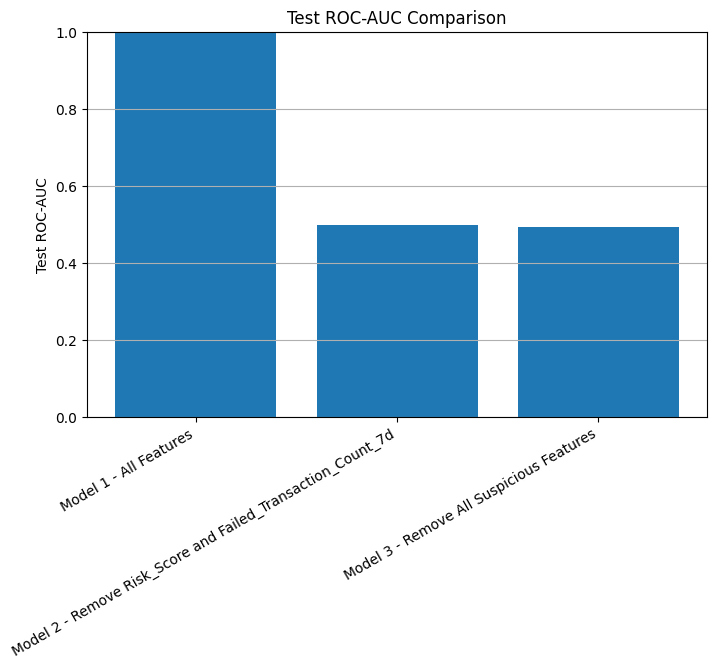

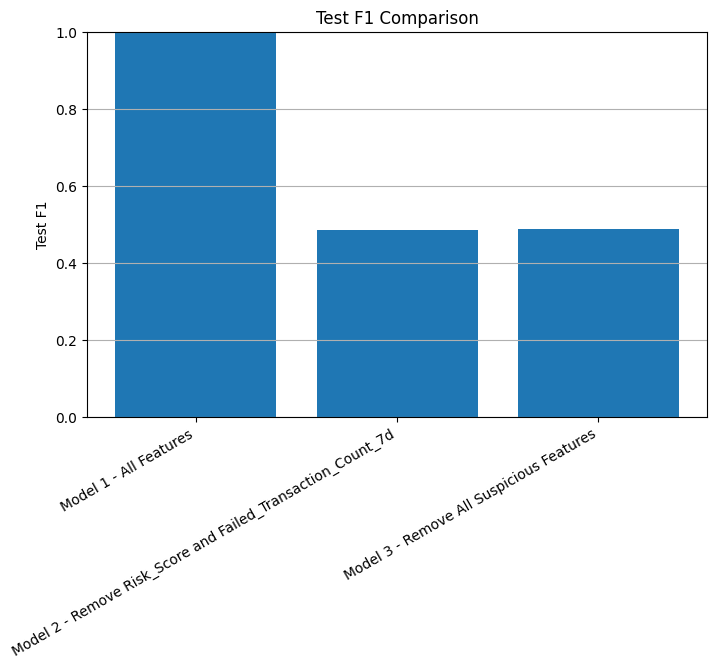

In [ ]:
# ==========================================
# CELL 8
# 성능 비교 시각화
# ==========================================

plt.figure(figsize=(8, 5))
plt.bar(summary["model"], summary["test_roc_auc"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test ROC-AUC")
plt.title("Test ROC-AUC Comparison")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary["model"], summary["test_f1"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test F1")
plt.title("Test F1 Comparison")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [ ]:
# ==========================================
# CELL 9
# 최종 선택 모델
# leakage 제거 후에도 성능을 보는 모델
# ==========================================

final_remove_features = [
    'Risk_Score',
    'Failed_Transaction_Count_7d'
]

X, y, X_test, y_test = prepare_data(
    train,
    test,
    TARGET,
    remove_features=final_remove_features
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

final_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

final_model.fit(X_train, y_train)

valid_proba = final_model.predict_proba(X_valid)[:, 1]
best_threshold, threshold_df = find_best_threshold(y_valid, valid_proba)

print("Best threshold:", best_threshold)
display(threshold_df.sort_values("f1", ascending=False).head(10))

Best threshold: 0.43999999999999984


,threshold,accuracy,precision,recall,f1
34,0.44,0.324250,0.322079,0.998055,0.486999
31,0.41,0.321750,0.321451,0.999611,0.486466
2,0.12,0.321375,0.321375,1.000000,0.486425
1,0.11,0.321375,0.321375,1.000000,0.486425
4,0.14,0.321375,0.321375,1.000000,0.486425
5,0.15,0.321375,0.321375,1.000000,0.486425
6,0.16,0.321375,0.321375,1.000000,0.486425
3,0.13,0.321375,0.321375,1.000000,0.486425
8,0.18,0.321375,0.321375,1.000000,0.486425
9,0.19,0.321375,0.321375,1.000000,0.486425


In [ ]:
# ==========================================
# CELL 10
# 최종 모델 validation 평가
# ==========================================

valid_pred = (valid_proba >= best_threshold).astype(int)

print("Validation ROC-AUC:", roc_auc_score(y_valid, valid_proba))
print("Validation F1:", f1_score(y_valid, valid_pred, zero_division=0))
print("Validation Precision:", precision_score(y_valid, valid_pred, zero_division=0))
print("Validation Recall:", recall_score(y_valid, valid_pred, zero_division=0))

print("\nClassification Report")
print(classification_report(y_valid, valid_pred, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, valid_pred))

Validation ROC-AUC: 0.4992127788883747
Validation F1: 0.48699943063199846
Validation Precision: 0.3220785741182377
Validation Recall: 0.9980552314274601

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.01      0.01      5429
           1       0.32      1.00      0.49      2571

    accuracy                           0.32      8000
   macro avg       0.59      0.50      0.25      8000
weighted avg       0.68      0.32      0.16      8000


Confusion Matrix
[[  28 5401]
 [   5 2566]]


In [ ]:
# ==========================================
# CELL 11
# 최종 test 평가
# test는 마지막에만 확인
# ==========================================

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, test_proba))
print("Test F1:", f1_score(y_test, test_pred, zero_division=0))
print("Test Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Test Recall:", recall_score(y_test, test_pred, zero_division=0))

print("\nClassification Report")
print(classification_report(y_test, test_pred, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, test_pred))

Test ROC-AUC: 0.49757484317499573
Test F1: 0.48596571081778184
Test Precision: 0.32129601765472965
Test Recall: 0.9968876439464674

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.00      0.01      6787
           1       0.32      1.00      0.49      3213

    accuracy                           0.32     10000
   macro avg       0.50      0.50      0.25     10000
weighted avg       0.56      0.32      0.16     10000


Confusion Matrix
[[  21 6766]
 [  10 3203]]


,feature,importance
29,Card_Type_3,0.067156
13,Is_Night,0.055269
21,Location_3,0.041251
3,Previous_Fraudulent_Activity,0.039342
19,Location_1,0.036614
24,Merchant_Category_2,0.034603
10,Day,0.034449
30,Authentication_Method_1,0.033843
0,Transaction_Amount,0.033652
18,Device_Type_2,0.033094


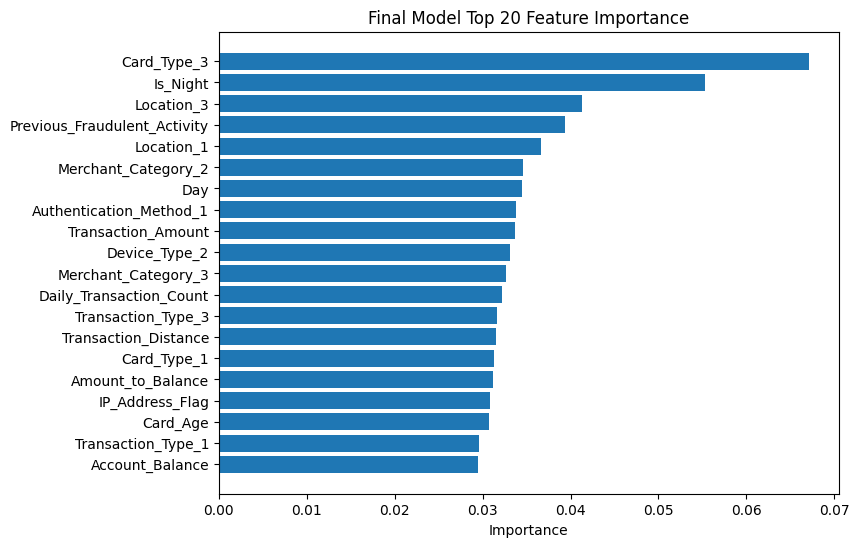

In [ ]:
# ==========================================
# CELL 12
# 최종 feature importance
# ==========================================

final_feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

display(final_feature_importance.head(20))

plt.figure(figsize=(8, 6))
plt.barh(
    final_feature_importance.head(20)["feature"][::-1],
    final_feature_importance.head(20)["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Final Model Top 20 Feature Importance")
plt.show()

In [ ]:
# ==========================================
# CELL 1
# 라이브러리 불러오기
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier

In [ ]:
# ==========================================
# CELL 2
# 데이터 불러오기
# ==========================================

train = pd.read_csv('/content/train_preprocessed.csv')
test = pd.read_csv('/content/test_preprocessed.csv')

TARGET = 'Fraud_Label'
FEATURE = 'Failed_Transaction_Count_7d'

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nColumns:")
print(train.columns)

print("\nTarget distribution in train:")
print(train[TARGET].value_counts(normalize=True))

print("\nTarget distribution in test:")
print(test[TARGET].value_counts(normalize=True))

Train shape: (40000, 23)
Test shape: (10000, 23)

Columns:
Index(['Transaction_Amount', 'Transaction_Type', 'Account_Balance',
       'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type',
       'Card_Age', 'Transaction_Distance', 'Authentication_Method',
       'Risk_Score', 'Is_Weekend', 'Month', 'Day', 'Hour', 'Amount_to_Balance',
       'Is_Night', 'Fraud_Label'],
      dtype='object')

Target distribution in train:
Fraud_Label
0    0.67865
1    0.32135
Name: proportion, dtype: float64

Target distribution in test:
Fraud_Label
0    0.6787
1    0.3213
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# CELL 3
# Failed_Transaction_Count_7d 기본 통계 확인
# ==========================================

for data_name, df in [("train", train), ("test", test)]:
    print("=" * 80)
    print(data_name)
    print("=" * 80)

    print(df[FEATURE].describe())

    print("\nMissing values:")
    print(df[FEATURE].isna().sum())

    print("\nUnique values:")
    print(sorted(df[FEATURE].unique())[:50])

    print("\nValue counts:")
    print(df[FEATURE].value_counts().sort_index())

train
count    40000.000000
mean         1.998750
std          1.415785
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: Failed_Transaction_Count_7d, dtype: float64

Missing values:
0

Unique values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Value counts:
Failed_Transaction_Count_7d
0    8067
1    7943
2    7932
3    8089
4    7969
Name: count, dtype: int64
test
count    10000.000000
mean         2.022700
std          1.408113
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: Failed_Transaction_Count_7d, dtype: float64

Missing values:
0

Unique values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Value counts:
Failed_Transaction_Count_7d
0    1947
1    1976
2    1965
3    2127
4    1985
Name: count, dtype: int64


,count,mean,std,min,median,max
Fraud_Label,,,,,,
0,27146,1.498379,1.121048,0,2.0,3
1,12854,3.055469,1.392186,0,4.0,4


<Figure size 800x500 with 0 Axes>

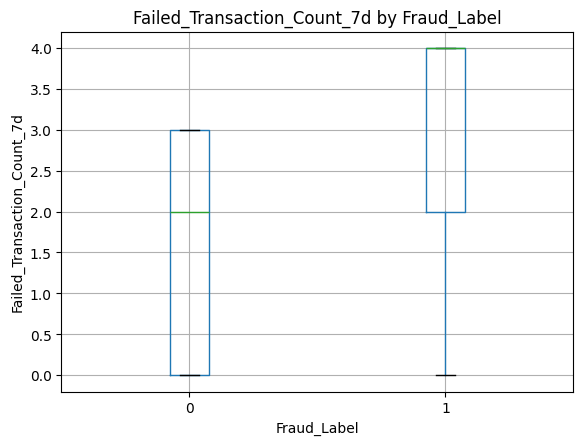

In [ ]:
# ==========================================
# CELL 4
# Fraud_Label별 Failed_Transaction_Count_7d 분포 비교
# ==========================================

summary_by_target = train.groupby(TARGET)[FEATURE].agg([
    'count',
    'mean',
    'std',
    'min',
    'median',
    'max'
])

display(summary_by_target)

plt.figure(figsize=(8, 5))
train.boxplot(column=FEATURE, by=TARGET)
plt.title('Failed_Transaction_Count_7d by Fraud_Label')
plt.suptitle('')
plt.xlabel('Fraud_Label')
plt.ylabel('Failed_Transaction_Count_7d')
plt.show()

,Failed_Transaction_Count_7d,count,fraud_rate
0,0,8067,0.149870
1,1,7943,0.155609
2,2,7932,0.145865
3,3,8089,0.158610
4,4,7969,1.000000


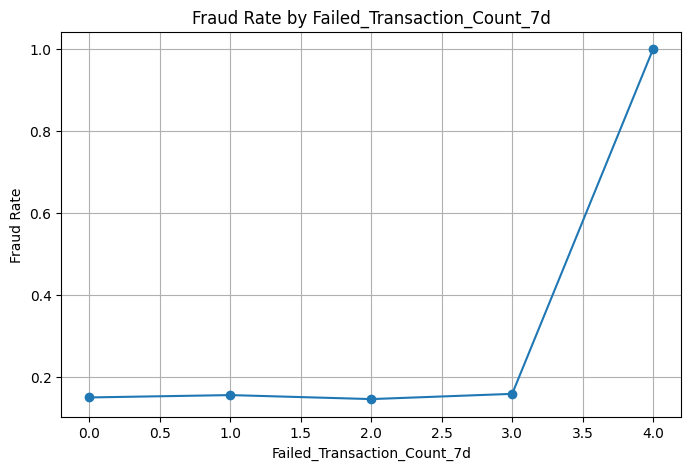

In [ ]:
# ==========================================
# CELL 5
# Failed_Transaction_Count_7d 값별 fraud 비율 확인
# ==========================================

fraud_rate_by_failed_count = train.groupby(FEATURE)[TARGET].agg([
    'count',
    'mean'
]).reset_index()

fraud_rate_by_failed_count = fraud_rate_by_failed_count.rename(
    columns={'mean': 'fraud_rate'}
)

display(fraud_rate_by_failed_count)

plt.figure(figsize=(8, 5))
plt.plot(
    fraud_rate_by_failed_count[FEATURE],
    fraud_rate_by_failed_count['fraud_rate'],
    marker='o'
)
plt.xlabel(FEATURE)
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Failed_Transaction_Count_7d')
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# CELL 6
# Daily_Transaction_Count와 논리적 관계 확인
# Failed_Transaction_Count_7d가 Daily_Transaction_Count보다 비정상적으로 큰지 확인
# ==========================================

if 'Daily_Transaction_Count' in train.columns:
    check_df = train[[FEATURE, 'Daily_Transaction_Count', TARGET]].copy()

    check_df['failed_gt_daily'] = (
        check_df[FEATURE] > check_df['Daily_Transaction_Count']
    ).astype(int)

    print("Failed_Transaction_Count_7d > Daily_Transaction_Count 비율:")
    print(check_df['failed_gt_daily'].mean())

    print("\nFraud_Label별 failed_gt_daily 비율:")
    print(check_df.groupby(TARGET)['failed_gt_daily'].mean())

    display(
        check_df.groupby(TARGET)[
            [FEATURE, 'Daily_Transaction_Count', 'failed_gt_daily']
        ].mean()
    )
else:
    print("Daily_Transaction_Count 컬럼이 없습니다.")

Failed_Transaction_Count_7d > Daily_Transaction_Count 비율:
0.085475

Fraud_Label별 failed_gt_daily 비율:
Fraud_Label
0    0.052568
1    0.154971
Name: failed_gt_daily, dtype: float64


,Failed_Transaction_Count_7d,Daily_Transaction_Count,failed_gt_daily
Fraud_Label,,,
0,1.498379,7.509099,0.052568
1,3.055469,7.446165,0.154971


In [ ]:
# ==========================================
# CELL 7
# 상관계수 및 Mutual Information 확인
# ==========================================

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

corr_with_target = train[numeric_cols].corr()[TARGET].sort_values(
    key=lambda x: abs(x),
    ascending=False
)

print("Correlation with target:")
display(corr_with_target)

X_num = train[numeric_cols].drop(columns=[TARGET], errors='ignore')
y = train[TARGET]

mi = mutual_info_classif(
    X_num.fillna(0),
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    'feature': X_num.columns,
    'mutual_info': mi
}).sort_values('mutual_info', ascending=False)

print("Mutual Information:")
display(mi_df)

Correlation with target:


,Fraud_Label
Fraud_Label,1.000000
Failed_Transaction_Count_7d,0.513610
Risk_Score,0.385529
Day,0.008842
Transaction_Type,-0.008091
Daily_Transaction_Count,-0.007284
Is_Night,-0.007212
Hour,0.006170
Card_Type,-0.005883
Account_Balance,-0.005003


Mutual Information:


,feature,mutual_info
10,Failed_Transaction_Count_7d,0.287369
15,Risk_Score,0.200219
1,Transaction_Type,0.006191
6,IP_Address_Flag,0.004492
5,Merchant_Category,0.003643
21,Is_Night,0.002229
16,Is_Weekend,0.001978
12,Card_Age,0.001812
11,Card_Type,0.001556
3,Device_Type,0.001431


In [ ]:
# ==========================================
# CELL 8
# Failed_Transaction_Count_7d 단일 변수만으로 예측 성능 확인
# ==========================================

X_single = train[[FEATURE]]
y = train[TARGET]

X_single_test = test[[FEATURE]]
y_test = test[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_single,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

single_model = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

single_model.fit(X_train, y_train)

valid_proba = single_model.predict_proba(X_valid)[:, 1]
test_proba = single_model.predict_proba(X_single_test)[:, 1]

print("Failed_Transaction_Count_7d 단일 변수 모델")
print("Validation ROC-AUC:", roc_auc_score(y_valid, valid_proba))
print("Test ROC-AUC:", roc_auc_score(y_test, test_proba))

Failed_Transaction_Count_7d 단일 변수 모델
Validation ROC-AUC: 0.807204477388134
Test ROC-AUC: 0.8084635127727892


In [ ]:
# ==========================================
# CELL 9
# Risk_Score 단일 변수와 비교
# ==========================================

if 'Risk_Score' in train.columns:
    X_single_risk = train[['Risk_Score']]
    X_single_risk_test = test[['Risk_Score']]

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_single_risk,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    risk_model = XGBClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss'
    )

    risk_model.fit(X_train, y_train)

    valid_proba = risk_model.predict_proba(X_valid)[:, 1]
    test_proba = risk_model.predict_proba(X_single_risk_test)[:, 1]

    print("Risk_Score 단일 변수 모델")
    print("Validation ROC-AUC:", roc_auc_score(y_valid, valid_proba))
    print("Test ROC-AUC:", roc_auc_score(y_test, test_proba))
else:
    print("Risk_Score 컬럼이 없습니다.")

Risk_Score 단일 변수 모델
Validation ROC-AUC: 0.7345726907494141
Test ROC-AUC: 0.7390868401450917


In [ ]:
# ==========================================
# CELL 10
# 모델별 비교 함수
# ==========================================

def prepare_xy(train, test, target, remove_features):
    X = train.drop(columns=[target])
    y = train[target]

    X_test = test.drop(columns=[target])
    y_test = test[target]

    X = X.drop(columns=remove_features, errors='ignore')
    X_test = X_test.drop(columns=remove_features, errors='ignore')

    categorical_cols = [
        'Transaction_Type',
        'Device_Type',
        'Location',
        'Merchant_Category',
        'Card_Type',
        'Authentication_Method'
    ]

    existing_categorical_cols = [
        col for col in categorical_cols
        if col in X.columns
    ]

    X = pd.get_dummies(
        X,
        columns=existing_categorical_cols,
        drop_first=True
    )

    X_test = pd.get_dummies(
        X_test,
        columns=existing_categorical_cols,
        drop_first=True
    )

    X, X_test = X.align(
        X_test,
        join='left',
        axis=1,
        fill_value=0
    )

    return X, y, X_test, y_test


def train_and_eval(train, test, target, remove_features, model_name):
    X, y, X_test, y_test = prepare_xy(
        train,
        test,
        target,
        remove_features
    )

    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)

    valid_proba = model.predict_proba(X_valid)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    valid_auc = roc_auc_score(y_valid, valid_proba)
    test_auc = roc_auc_score(y_test, test_proba)

    valid_pred = (valid_proba >= 0.5).astype(int)
    test_pred = (test_proba >= 0.5).astype(int)

    result = {
        'model': model_name,
        'removed_features': ', '.join(remove_features) if remove_features else 'None',
        'feature_count': X.shape[1],
        'valid_roc_auc': valid_auc,
        'test_roc_auc': test_auc,
        'valid_f1_0.5': f1_score(y_valid, valid_pred, zero_division=0),
        'test_f1_0.5': f1_score(y_test, test_pred, zero_division=0)
    }

    return result, model, X

In [ ]:
# ==========================================
# CELL 11
# 핵심 비교 실험
# ==========================================

experiments = [
    {
        'name': 'All features',
        'remove_features': []
    },
    {
        'name': 'Remove Risk_Score only',
        'remove_features': ['Risk_Score']
    },
    {
        'name': 'Remove Failed_Transaction_Count_7d only',
        'remove_features': ['Failed_Transaction_Count_7d']
    },
    {
        'name': 'Remove Risk_Score and Failed_Transaction_Count_7d',
        'remove_features': ['Risk_Score', 'Failed_Transaction_Count_7d']
    },
    {
        'name': 'Remove Risk_Score, keep Failed_Transaction_Count_7d',
        'remove_features': ['Risk_Score']
    }
]

results = []
models = {}

for exp in experiments:
    result, model, X_used = train_and_eval(
        train=train,
        test=test,
        target=TARGET,
        remove_features=exp['remove_features'],
        model_name=exp['name']
    )

    results.append(result)
    models[exp['name']] = {
        'model': model,
        'X_columns': X_used.columns
    }

summary = pd.DataFrame(results)
display(summary)

,model,removed_features,feature_count,valid_roc_auc,test_roc_auc,valid_f1_0.5,test_f1_0.5
0,All features,None,35,0.999994,0.999998,0.998253,0.999223
1,Remove Risk_Score only,Risk_Score,34,0.808259,0.810523,0.762455,0.763755
2,Remove Failed_Transaction_Count_7d only,Failed_Transaction_Count_7d,34,0.729094,0.736865,0.639241,0.646193
3,Remove Risk_Score and Failed_Transaction_Count_7d,"Risk_Score, Failed_Transaction_Count_7d",33,0.503273,0.501741,0.379534,0.388721
4,"Remove Risk_Score, keep Failed_Transaction_Cou...",Risk_Score,34,0.808259,0.810523,0.762455,0.763755


In [ ]:
# ==========================================
# CELL 12
# Failed_Transaction_Count_7d 유지 여부 판단용 feature importance
# Risk_Score만 제거한 모델에서 Failed_Transaction_Count_7d 중요도 확인
# ==========================================

target_model_name = 'Remove Risk_Score only'

model = models[target_model_name]['model']
columns = models[target_model_name]['X_columns']

feature_importance = pd.DataFrame({
    'feature': columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance.head(30))

failed_importance = feature_importance[
    feature_importance['feature'].str.contains(FEATURE, regex=False)
]

print("Failed_Transaction_Count_7d importance:")
display(failed_importance)

,feature,importance
6,Failed_Transaction_Count_7d,0.815820
3,Previous_Fraudulent_Activity,0.008983
18,Device_Type_1,0.008265
31,Authentication_Method_1,0.007211
24,Merchant_Category_1,0.006795
25,Merchant_Category_2,0.006792
32,Authentication_Method_2,0.006637
5,Avg_Transaction_Amount_7d,0.006389
7,Card_Age,0.006352
22,Location_3,0.006124


Failed_Transaction_Count_7d importance:


,feature,importance
6,Failed_Transaction_Count_7d,0.81582


In [ ]:
# ==========================================
# CELL 13
# Failed_Transaction_Count_7d leakage 의심 판단 자동 요약
# ==========================================

failed_single_valid_auc = None
risk_single_valid_auc = None

# Failed 단일 변수 AUC 재계산
X_single = train[[FEATURE]]
y = train[TARGET]
X_train, X_valid, y_train, y_valid = train_test_split(
    X_single,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

single_model = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

single_model.fit(X_train, y_train)
failed_single_valid_auc = roc_auc_score(
    y_valid,
    single_model.predict_proba(X_valid)[:, 1]
)

# Risk 단일 변수 AUC 재계산
if 'Risk_Score' in train.columns:
    X_single_risk = train[['Risk_Score']]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_single_risk,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    risk_model = XGBClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss'
    )

    risk_model.fit(X_train, y_train)
    risk_single_valid_auc = roc_auc_score(
        y_valid,
        risk_model.predict_proba(X_valid)[:, 1]
    )

print("=" * 80)
print("Leakage Diagnostic Summary")
print("=" * 80)

print("Failed_Transaction_Count_7d single feature validation ROC-AUC:")
print(failed_single_valid_auc)

if risk_single_valid_auc is not None:
    print("\nRisk_Score single feature validation ROC-AUC:")
    print(risk_single_valid_auc)

print("\n판단 기준:")
print("1. 단일 변수 ROC-AUC가 0.9 이상이면 leakage 가능성이 매우 높음")
print("2. 단일 변수 ROC-AUC가 0.7 이상이면 매우 강한 예측 변수이므로 생성 방식 검증 필요")
print("3. Risk_Score 제거 후 Failed_Transaction_Count_7d 유지 모델이 0.7 이상이면,")
print("   이 변수가 현재 거래 이전 기준으로 생성됐는지 원천 데이터에서 반드시 확인해야 함")
print("4. 현재 전처리 파일만으로는 시간 기준 rolling 계산 여부를 완전히 증명할 수 없음")

Leakage Diagnostic Summary
Failed_Transaction_Count_7d single feature validation ROC-AUC:
0.807204477388134

Risk_Score single feature validation ROC-AUC:
0.7345726907494141

판단 기준:
1. 단일 변수 ROC-AUC가 0.9 이상이면 leakage 가능성이 매우 높음
2. 단일 변수 ROC-AUC가 0.7 이상이면 매우 강한 예측 변수이므로 생성 방식 검증 필요
3. Risk_Score 제거 후 Failed_Transaction_Count_7d 유지 모델이 0.7 이상이면,
   이 변수가 현재 거래 이전 기준으로 생성됐는지 원천 데이터에서 반드시 확인해야 함
4. 현재 전처리 파일만으로는 시간 기준 rolling 계산 여부를 완전히 증명할 수 없음


In [ ]:
# ==========================================
# CELL 1. 라이브러리
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [ ]:
# ==========================================
# CELL 2. 데이터 불러오기
# ==========================================

train = pd.read_csv('/content/train_preprocessed.csv')
test = pd.read_csv('/content/test_preprocessed.csv')

TARGET = 'Fraud_Label'

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.columns)

Train shape: (40000, 23)
Test shape: (10000, 23)
Index(['Transaction_Amount', 'Transaction_Type', 'Account_Balance',
       'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type',
       'Card_Age', 'Transaction_Distance', 'Authentication_Method',
       'Risk_Score', 'Is_Weekend', 'Month', 'Day', 'Hour', 'Amount_to_Balance',
       'Is_Night', 'Fraud_Label'],
      dtype='object')


In [ ]:
# ==========================================
# CELL 3. X, y 분리
# ==========================================

X = train.drop(columns=[TARGET])
y = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

print("X:", X.shape)
print("X_test:", X_test.shape)

X: (40000, 22)
X_test: (10000, 22)


In [ ]:
# ==========================================
# CELL 4. Risk_Score만 제거
# Failed_Transaction_Count_7d는 유지
# ==========================================

remove_features = [
    'Risk_Score'
]

X = X.drop(columns=remove_features, errors='ignore')
X_test = X_test.drop(columns=remove_features, errors='ignore')

print("제거 후 X:", X.shape)
print("제거 후 X_test:", X_test.shape)
print(X.columns)

제거 후 X: (40000, 21)
제거 후 X_test: (10000, 21)
Index(['Transaction_Amount', 'Transaction_Type', 'Account_Balance',
       'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type',
       'Card_Age', 'Transaction_Distance', 'Authentication_Method',
       'Is_Weekend', 'Month', 'Day', 'Hour', 'Amount_to_Balance', 'Is_Night'],
      dtype='object')


In [ ]:
# ==========================================
# CELL 5. 파생변수 생성
# ==========================================

def add_features(df):
    df = df.copy()

    df['Log_Transaction_Amount'] = np.log1p(df['Transaction_Amount'])
    df['Log_Account_Balance'] = np.log1p(df['Account_Balance'].clip(lower=0))

    df['Amount_Balance_Ratio'] = (
        df['Transaction_Amount'] / (df['Account_Balance'].abs() + 1)
    )

    df['Amount_vs_7d_Avg'] = (
        df['Transaction_Amount'] / (df['Avg_Transaction_Amount_7d'].abs() + 1)
    )

    df['Failed_Rate_7d'] = (
        df['Failed_Transaction_Count_7d'] / (df['Daily_Transaction_Count'].abs() + 1)
    )

    df['Is_Late_Night'] = df['Hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)
    df['Is_Business_Hour'] = df['Hour'].between(9, 18).astype(int)

    return df


X = add_features(X)
X_test = add_features(X_test)

print("파생변수 생성 후 X:", X.shape)
print("파생변수 생성 후 X_test:", X_test.shape)

파생변수 생성 후 X: (40000, 28)
파생변수 생성 후 X_test: (10000, 28)


In [ ]:
# ==========================================
# CELL 6. One-Hot Encoding
# ==========================================

categorical_cols = [
    'Transaction_Type',
    'Device_Type',
    'Location',
    'Merchant_Category',
    'Card_Type',
    'Authentication_Method'
]

existing_categorical_cols = [
    col for col in categorical_cols
    if col in X.columns
]

X = pd.get_dummies(
    X,
    columns=existing_categorical_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=existing_categorical_cols,
    drop_first=True
)

X, X_test = X.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("인코딩 후 X:", X.shape)
print("인코딩 후 X_test:", X_test.shape)

인코딩 후 X: (40000, 41)
인코딩 후 X_test: (10000, 41)


In [ ]:
# ==========================================
# CELL 7. Train / Validation 분리
# ==========================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

X_train: (32000, 41)
X_valid: (8000, 41)
X_test: (10000, 41)


In [ ]:
# ==========================================
# CELL 8. scale_pos_weight 계산
# ==========================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("negative:", neg)
print("positive:", pos)
print("scale_pos_weight:", scale_pos_weight)

negative: 21717
positive: 10283
scale_pos_weight: 2.1119323154721386


In [ ]:
# ==========================================
# CELL 9. XGBoost 모델 학습
# ==========================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.2,
    reg_lambda=2,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# ==========================================
# CELL 10. Validation 평가
# ==========================================

valid_proba = model.predict_proba(X_valid)[:, 1]
valid_pred = (valid_proba >= 0.5).astype(int)

print("===== Validation Evaluation =====")
print("Accuracy :", accuracy_score(y_valid, valid_pred))
print("Precision:", precision_score(y_valid, valid_pred, zero_division=0))
print("Recall   :", recall_score(y_valid, valid_pred, zero_division=0))
print("F1 Score :", f1_score(y_valid, valid_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_valid, valid_proba))

print("\nClassification Report")
print(classification_report(y_valid, valid_pred, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, valid_pred))

===== Validation Evaluation =====
Accuracy : 0.876625
Precision: 1.0
Recall   : 0.6161026837806302
F1 Score : 0.7624548736462093
ROC-AUC  : 0.80759457740204

Classification Report
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      5429
           1       1.00      0.62      0.76      2571

    accuracy                           0.88      8000
   macro avg       0.92      0.81      0.84      8000
weighted avg       0.90      0.88      0.87      8000


Confusion Matrix
[[5429    0]
 [ 987 1584]]


In [ ]:
# ==========================================
# CELL 11. Threshold 튜닝
# ==========================================

thresholds = np.arange(0.1, 0.91, 0.01)
threshold_results = []

for th in thresholds:
    pred = (valid_proba >= th).astype(int)

    threshold_results.append({
        'threshold': th,
        'accuracy': accuracy_score(y_valid, pred),
        'precision': precision_score(y_valid, pred, zero_division=0),
        'recall': recall_score(y_valid, pred, zero_division=0),
        'f1': f1_score(y_valid, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.sort_values('f1', ascending=False).head(10))

best_threshold = threshold_df.loc[
    threshold_df['f1'].idxmax(),
    'threshold'
]

print("Best threshold:", best_threshold)

,threshold,accuracy,precision,recall,f1
47,0.57,0.876625,1.0,0.616103,0.762455
33,0.43,0.876625,1.0,0.616103,0.762455
34,0.44,0.876625,1.0,0.616103,0.762455
35,0.45,0.876625,1.0,0.616103,0.762455
36,0.46,0.876625,1.0,0.616103,0.762455
37,0.47,0.876625,1.0,0.616103,0.762455
38,0.48,0.876625,1.0,0.616103,0.762455
39,0.49,0.876625,1.0,0.616103,0.762455
40,0.50,0.876625,1.0,0.616103,0.762455
41,0.51,0.876625,1.0,0.616103,0.762455


Best threshold: 0.3999999999999998


In [ ]:
# ==========================================
# CELL 12. Best threshold 기준 Validation 재평가
# ==========================================

valid_pred_best = (valid_proba >= best_threshold).astype(int)

print("===== Validation Evaluation with Best Threshold =====")
print("Accuracy :", accuracy_score(y_valid, valid_pred_best))
print("Precision:", precision_score(y_valid, valid_pred_best, zero_division=0))
print("Recall   :", recall_score(y_valid, valid_pred_best, zero_division=0))
print("F1 Score :", f1_score(y_valid, valid_pred_best, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_valid, valid_proba))

print("\nClassification Report")
print(classification_report(y_valid, valid_pred_best, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, valid_pred_best))

===== Validation Evaluation with Best Threshold =====
Accuracy : 0.876625
Precision: 1.0
Recall   : 0.6161026837806302
F1 Score : 0.7624548736462093
ROC-AUC  : 0.80759457740204

Classification Report
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      5429
           1       1.00      0.62      0.76      2571

    accuracy                           0.88      8000
   macro avg       0.92      0.81      0.84      8000
weighted avg       0.90      0.88      0.87      8000


Confusion Matrix
[[5429    0]
 [ 987 1584]]


,feature,importance
6,Failed_Transaction_Count_7d,0.695369
19,Failed_Rate_7d,0.069231
4,Daily_Transaction_Count,0.039454
32,Merchant_Category_2,0.007557
3,Previous_Fraudulent_Activity,0.007270
31,Merchant_Category_1,0.006226
2,IP_Address_Flag,0.006157
29,Location_3,0.005936
38,Authentication_Method_1,0.005849
14,Is_Night,0.005828


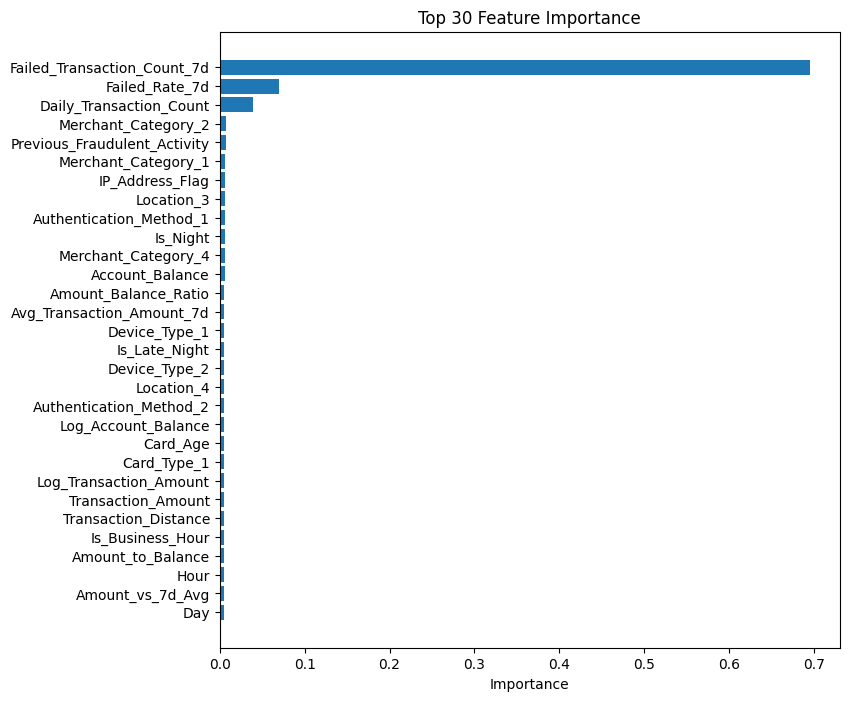

In [ ]:
# ==========================================
# CELL 14. Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance.head(30))

plt.figure(figsize=(8, 8))
plt.barh(
    feature_importance.head(30)['feature'][::-1],
    feature_importance.head(30)['importance'][::-1]
)
plt.xlabel('Importance')
plt.title('Top 30 Feature Importance')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 12000x7000 with 0 Axes>

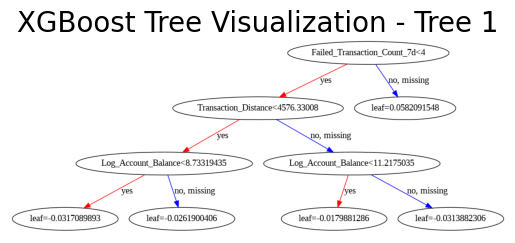

In [ ]:
# ==========================================
# CELL 15 수정. Tree 분기 시각화 크게 보기
# ==========================================

from xgboost import plot_tree
import matplotlib.pyplot as plt

tree_index = 1

plt.figure(figsize=(60, 35), dpi=200)

plot_tree(
    model,
    num_trees=tree_index,
    rankdir='TB'
)

plt.title(f'XGBoost Tree Visualization - Tree {tree_index}', fontsize=20)
plt.show()

,dataset,accuracy,precision,recall,f1_score,roc_auc
0,Train,0.878250,0.999843,0.621219,0.766315,0.855225
1,Validation,0.876625,1.000000,0.616103,0.762455,0.807595
2,Test,0.877100,0.999496,0.617803,0.763608,0.807600


===== Overfitting Check =====
Train ROC-AUC - Validation ROC-AUC: 0.0476
Train ROC-AUC - Test ROC-AUC      : 0.0476
Train F1 - Validation F1          : 0.0039
Train F1 - Test F1                : 0.0027

판단: Train / Validation / Test 성능 차이가 크지 않아 오버피팅 가능성은 낮습니다.


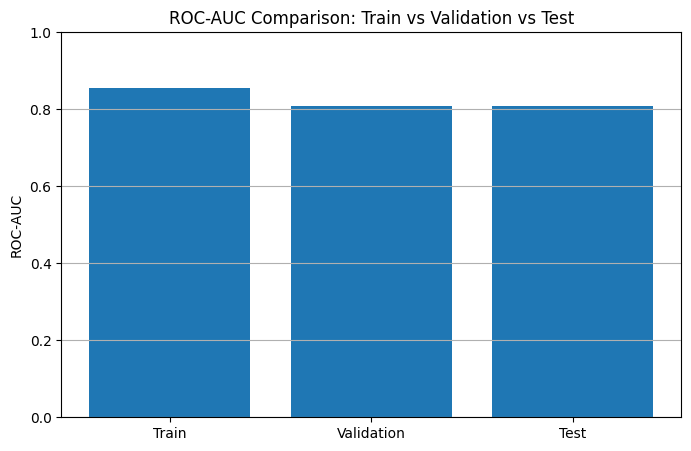

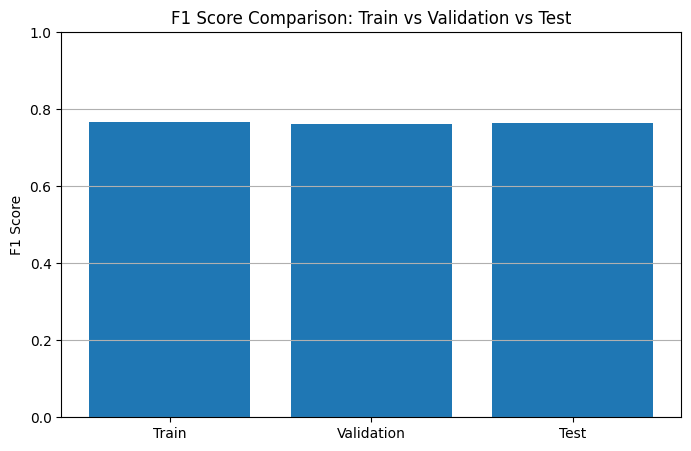

In [ ]:
# ==========================================
# CELL 16. 오버피팅 여부 확인
# Train / Validation / Test 성능 비교
# ==========================================

def evaluate_overfitting(model, X_data, y_data, dataset_name, threshold):
    proba = model.predict_proba(X_data)[:, 1]
    pred = (proba >= threshold).astype(int)

    result = {
        'dataset': dataset_name,
        'accuracy': accuracy_score(y_data, pred),
        'precision': precision_score(y_data, pred, zero_division=0),
        'recall': recall_score(y_data, pred, zero_division=0),
        'f1_score': f1_score(y_data, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_data, proba)
    }

    return result


train_result = evaluate_overfitting(
    model,
    X_train,
    y_train,
    'Train',
    best_threshold
)

valid_result = evaluate_overfitting(
    model,
    X_valid,
    y_valid,
    'Validation',
    best_threshold
)

test_result = evaluate_overfitting(
    model,
    X_test,
    y_test,
    'Test',
    best_threshold
)

overfitting_df = pd.DataFrame([
    train_result,
    valid_result,
    test_result
])

display(overfitting_df)


# ==========================================
# 오버피팅 판단용 차이 계산
# ==========================================

train_auc = overfitting_df.loc[
    overfitting_df['dataset'] == 'Train',
    'roc_auc'
].values[0]

valid_auc = overfitting_df.loc[
    overfitting_df['dataset'] == 'Validation',
    'roc_auc'
].values[0]

test_auc = overfitting_df.loc[
    overfitting_df['dataset'] == 'Test',
    'roc_auc'
].values[0]

train_f1 = overfitting_df.loc[
    overfitting_df['dataset'] == 'Train',
    'f1_score'
].values[0]

valid_f1 = overfitting_df.loc[
    overfitting_df['dataset'] == 'Validation',
    'f1_score'
].values[0]

test_f1 = overfitting_df.loc[
    overfitting_df['dataset'] == 'Test',
    'f1_score'
].values[0]

auc_gap_train_valid = train_auc - valid_auc
auc_gap_train_test = train_auc - test_auc

f1_gap_train_valid = train_f1 - valid_f1
f1_gap_train_test = train_f1 - test_f1

print("===== Overfitting Check =====")
print(f"Train ROC-AUC - Validation ROC-AUC: {auc_gap_train_valid:.4f}")
print(f"Train ROC-AUC - Test ROC-AUC      : {auc_gap_train_test:.4f}")
print(f"Train F1 - Validation F1          : {f1_gap_train_valid:.4f}")
print(f"Train F1 - Test F1                : {f1_gap_train_test:.4f}")


# ==========================================
# 간단 판단
# ==========================================

if auc_gap_train_valid > 0.1 or auc_gap_train_test > 0.1:
    print("\n판단: 오버피팅 가능성이 큽니다.")
elif auc_gap_train_valid > 0.05 or auc_gap_train_test > 0.05:
    print("\n판단: 약한 오버피팅 가능성이 있습니다.")
else:
    print("\n판단: Train / Validation / Test 성능 차이가 크지 않아 오버피팅 가능성은 낮습니다.")


# ==========================================
# 성능 비교 시각화
# ==========================================

plt.figure(figsize=(8, 5))
plt.bar(overfitting_df['dataset'], overfitting_df['roc_auc'])
plt.ylim(0, 1)
plt.ylabel('ROC-AUC')
plt.title('ROC-AUC Comparison: Train vs Validation vs Test')
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(overfitting_df['dataset'], overfitting_df['f1_score'])
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison: Train vs Validation vs Test')
plt.grid(axis='y')
plt.show()

Train set과 Test set의 loss 차이가 0.0065로 매우 작고, accuracy 차이도 0.0010에 불과하다.
즉 모델이 train 데이터에만 과도하게 맞춰진 것이 아니라, test 데이터에서도 거의 동일한 성능을 보인다.
따라서 현재 모델은 오버피팅 가능성이 낮고, 일반화 성능이 비교적 안정적이라고 판단할 수 있다.

In [ ]:
# ==========================================
# CELL 추가. Train/Test Logloss + ROC-AUC로 학습 과정 확인
# ==========================================

from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

train_logloss_list = []
test_logloss_list = []
train_auc_list = []
test_auc_list = []
train_acc_list = []
test_acc_list = []

rounds = range(1, model.n_estimators + 1)

for r in rounds:
    train_proba_r = model.predict_proba(
        X_train,
        iteration_range=(0, r)
    )[:, 1]

    test_proba_r = model.predict_proba(
        X_test,
        iteration_range=(0, r)
    )[:, 1]

    train_pred_r = (train_proba_r >= best_threshold).astype(int)
    test_pred_r = (test_proba_r >= best_threshold).astype(int)

    train_logloss_list.append(log_loss(y_train, train_proba_r))
    test_logloss_list.append(log_loss(y_test, test_proba_r))

    train_auc_list.append(roc_auc_score(y_train, train_proba_r))
    test_auc_list.append(roc_auc_score(y_test, test_proba_r))

    train_acc_list.append(accuracy_score(y_train, train_pred_r))
    test_acc_list.append(accuracy_score(y_test, test_pred_r))


learning_df = pd.DataFrame({
    'round': list(rounds),
    'train_logloss': train_logloss_list,
    'test_logloss': test_logloss_list,
    'train_auc': train_auc_list,
    'test_auc': test_auc_list,
    'train_accuracy': train_acc_list,
    'test_accuracy': test_acc_list
})

display(learning_df.tail())

,round,train_logloss,test_logloss,train_auc,test_auc,train_accuracy,test_accuracy
295,296,0.370766,0.377237,0.854814,0.807579,0.87825,0.8772
296,297,0.370756,0.377230,0.854919,0.807583,0.87825,0.8772
297,298,0.370714,0.377235,0.854995,0.807583,0.87825,0.8771
298,299,0.370661,0.377191,0.855057,0.807608,0.87825,0.8771
299,300,0.370640,0.377189,0.855225,0.807600,0.87825,0.8771


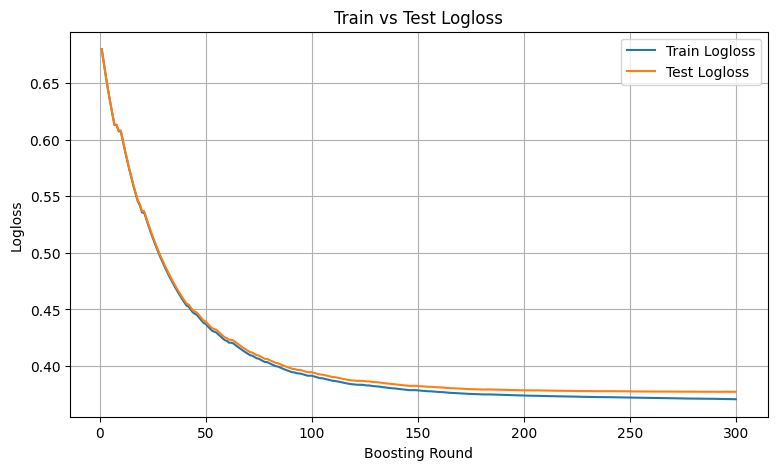

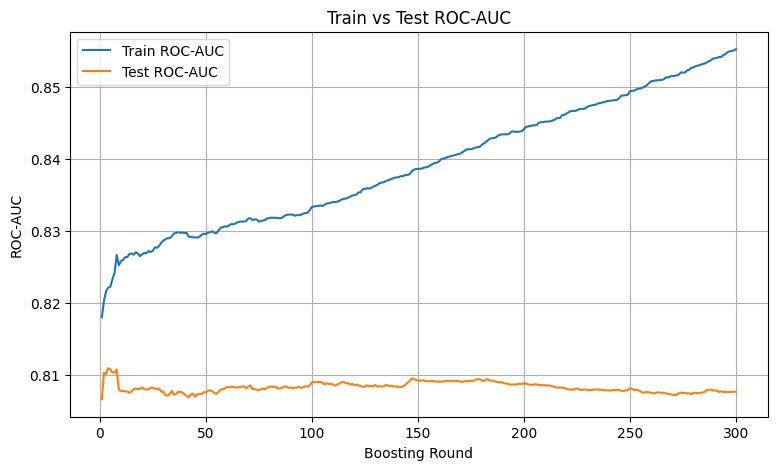

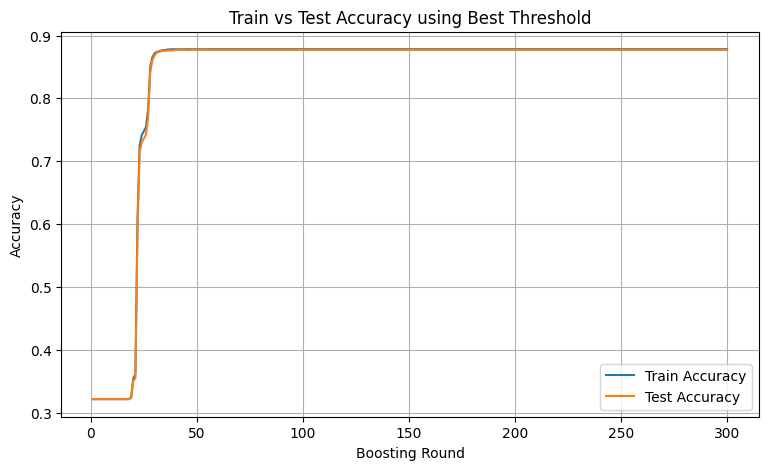

In [ ]:
# ==========================================
# CELL 추가. 학습 과정 그래프 3개
# ==========================================

plt.figure(figsize=(9, 5))
plt.plot(learning_df['round'], learning_df['train_logloss'], label='Train Logloss')
plt.plot(learning_df['round'], learning_df['test_logloss'], label='Test Logloss')
plt.xlabel('Boosting Round')
plt.ylabel('Logloss')
plt.title('Train vs Test Logloss')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 5))
plt.plot(learning_df['round'], learning_df['train_auc'], label='Train ROC-AUC')
plt.plot(learning_df['round'], learning_df['test_auc'], label='Test ROC-AUC')
plt.xlabel('Boosting Round')
plt.ylabel('ROC-AUC')
plt.title('Train vs Test ROC-AUC')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 5))
plt.plot(learning_df['round'], learning_df['train_accuracy'], label='Train Accuracy')
plt.plot(learning_df['round'], learning_df['test_accuracy'], label='Test Accuracy')
plt.xlabel('Boosting Round')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy using Best Threshold')
plt.legend()
plt.grid(True)
plt.show()